# Analyzing the causal effect of the tax rate (STCG/LTCG) on the FPI inflow/outflows?

In [74]:
# ============================================================
# FPI Equity Flow Causal Setup: Tax + NIFTY 200 + NEER + China FX
# Period: Jan-2021 onward
# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load your uploaded FPI file
# -----------------------------
file_path = "FPI.xlsx"

df = pd.read_excel(file_path)

print(df.head())
print(df.columns)
print(df.shape)

       Month  FPI_inflow  Nifty_50_Close_Price  NIFTY_200_Close   NEER
0 2026-04-01       -6489              23997.55         13705.55  89.71
1 2026-03-01      -12576              22331.40         12492.10  90.98
2 2026-02-01        2491              25178.65         14121.05  91.98
3 2026-01-01       -3952              25320.65         14093.05  93.20
4 2025-12-01       -2497              26129.60         14533.50  94.15
Index(['Month', 'FPI_inflow', 'Nifty_50_Close_Price', 'NIFTY_200_Close',
       'NEER'],
      dtype='object')
(64, 5)


In [75]:
# -----------------------------
# 2. Clean date and sort
# -----------------------------
df["Month"] = pd.to_datetime(df["Month"])
df = df.sort_values("Month").reset_index(drop=True)

# Keep month as month-start date
df["Month"] = df["Month"].dt.to_period("M").dt.to_timestamp()

print(df.head())
print(df.tail())

       Month  FPI_inflow  Nifty_50_Close_Price  NIFTY_200_Close   NEER
0 2021-01-01        2667              13634.60          7076.80  97.74
1 2021-02-01        3546              14529.15          7591.25  97.97
2 2021-03-01        1431              14690.70          7671.60  99.23
3 2021-04-01       -1297              14631.10          7683.95  97.29
4 2021-05-01        -397              15582.80          8204.90  99.72
        Month  FPI_inflow  Nifty_50_Close_Price  NIFTY_200_Close   NEER
59 2025-12-01       -2497              26129.60         14533.50  94.15
60 2026-01-01       -3952              25320.65         14093.05  93.20
61 2026-02-01        2491              25178.65         14121.05  91.98
62 2026-03-01      -12576              22331.40         12492.10  90.98
63 2026-04-01       -6489              23997.55         13705.55  89.71


In [76]:
# ============================================================
# Replace NEER with USD/INR exchange rate
# Keep variable name as NEER so later code does not change
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np

# Make sure Month is clean
df["Month"] = pd.to_datetime(df["Month"])
df["Month"] = df["Month"].dt.to_period("M").dt.to_timestamp()
df = df.sort_values("Month").reset_index(drop=True)

# Download USD/INR from yfinance
start_date = df["Month"].min().strftime("%Y-%m-%d")
end_date = (df["Month"].max() + pd.DateOffset(months=2)).strftime("%Y-%m-%d")

usdinr_raw = yf.download(
    "INR=X",
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=True,
    progress=False
)

# Get close price
usdinr_daily = usdinr_raw["Close"].copy()

# Convert to monthly month-start data
usdinr_monthly = usdinr_daily.resample("MS").last().reset_index()

# Fix column names robustly
usdinr_monthly.columns = ["Month", "USDINR"]

usdinr_monthly["Month"] = pd.to_datetime(usdinr_monthly["Month"]).dt.to_period("M").dt.to_timestamp()

# Merge into main data
df = df.drop(columns=["NEER"], errors="ignore")
df = df.merge(usdinr_monthly, on="Month", how="left")

# Rename USDINR as NEER so all old code keeps working
df = df.rename(columns={"USDINR": "NEER"})

print(df[["Month", "NEER"]].head())
print(df[["Month", "NEER"]].tail())

       Month       NEER
0 2021-01-01  72.938797
1 2021-02-01  73.150902
2 2021-03-01  73.445297
3 2021-04-01  74.105797
4 2021-05-01  72.393501
        Month       NEER
59 2025-12-01  89.769402
60 2026-01-01  91.781898
61 2026-02-01  91.007401
62 2026-03-01  94.355904
63 2026-04-01  94.916603


In [77]:
# ============================================================
# Keep same variable names
# Here NEER actually means USD/INR exchange rate
# ============================================================

df["neer_return"] = 100 * np.log(df["NEER"] / df["NEER"].shift(1))

# Since USD/INR rising means INR depreciation,
# neer_return itself is depreciation pressure.
df["neer_depreciation"] = df["neer_return"]

df[["Month", "NEER", "neer_return", "neer_depreciation"]].head(10)

,Month,NEER,neer_return,neer_depreciation
0,2021-01-01,72.938797,NaN,NaN
1,2021-02-01,73.150902,0.290376,0.290376
2,2021-03-01,73.445297,0.401642,0.401642
3,2021-04-01,74.105797,0.895288,0.895288
4,2021-05-01,72.393501,-2.337722,-2.337722
5,2021-06-01,74.287598,2.582748,2.582748
6,2021-07-01,74.251999,-0.047932,-0.047932
7,2021-08-01,73.411201,-1.138817,-1.138817
8,2021-09-01,74.321999,1.233045,1.233045
9,2021-10-01,74.797203,0.637351,0.637351


In [78]:
# -----------------------------
# 3. Create India market return and NEER depreciation
# -----------------------------

# NIFTY 200 return
df["nifty200_return"] = 100 * np.log(
    df["NIFTY_200_Close"] / df["NIFTY_200_Close"].shift(1)
)

# Lagged NIFTY 200 return
# This avoids simultaneity problem:
# FPI flows and same-month market returns affect each other.
df["nifty200_return_lag1"] = df["nifty200_return"].shift(1)
df[["Month", "FPI_inflow", "nifty200_return", "nifty200_return_lag1", "neer_return", "neer_depreciation"]].head(10)

,Month,FPI_inflow,nifty200_return,nifty200_return_lag1,neer_return,neer_depreciation
0,2021-01-01,2667,NaN,NaN,NaN,NaN
1,2021-02-01,3546,7.017444,NaN,0.290376,0.290376
2,2021-03-01,1431,1.052893,7.017444,0.401642,0.401642
3,2021-04-01,-1297,0.160854,1.052893,0.895288,0.895288
4,2021-05-01,-397,6.559780,0.160854,-2.337722,-2.337722
5,2021-06-01,2348,1.459756,6.559780,2.582748,2.582748
6,2021-07-01,-1519,0.844417,1.459756,-0.047932,-0.047932
7,2021-08-01,281,7.225294,0.844417,-1.138817,-1.138817
8,2021-09-01,1780,3.198083,7.225294,1.233045,1.233045
9,2021-10-01,-1812,0.210648,3.198083,0.637351,0.637351


In [79]:
# -----------------------------
# 4. Tax variables: LTCG/STCG change
# -----------------------------

tax_date = pd.Timestamp("2024-07-01")

# Event month dummy
df["tax_event_jul2024"] = (df["Month"] == tax_date).astype(int)

# Post-tax dummy
# Use August 2024 onward as post period because July is announcement/implementation month.
df["post_tax_jul2024"] = (df["Month"] >= pd.Timestamp("2024-08-01")).astype(int)

# Event window: June, July, August 2024
df["tax_event_window_1m"] = (
    (df["Month"] >= pd.Timestamp("2024-06-01")) &
    (df["Month"] <= pd.Timestamp("2024-08-01"))
).astype(int)

# Wider window: May to September 2024
df["tax_event_window_2m"] = (
    (df["Month"] >= pd.Timestamp("2024-05-01")) &
    (df["Month"] <= pd.Timestamp("2024-09-01"))
).astype(int)

# Tax rates
df["stcg_rate"] = np.where(df["Month"] >= tax_date, 20.0, 15.0)
df["ltcg_rate"] = np.where(df["Month"] >= tax_date, 12.5, 10.0)

# Tax burden index
# More weight to STCG because FPI equity flows are more active/short-horizon.
df["tax_burden_index"] = 0.7 * df["stcg_rate"] + 0.3 * df["ltcg_rate"]

df[[
    "Month", "FPI_inflow", "tax_event_jul2024", "post_tax_jul2024",
    "stcg_rate", "ltcg_rate", "tax_burden_index"
]].tail(25)

,Month,FPI_inflow,tax_event_jul2024,post_tax_jul2024,stcg_rate,ltcg_rate,tax_burden_index
39,2024-04-01,-1038,0,0,15.0,10.0,13.50
40,2024-05-01,-3064,0,0,15.0,10.0,13.50
41,2024-06-01,3183,0,0,15.0,10.0,13.50
42,2024-07-01,3871,1,0,20.0,12.5,17.75
43,2024-08-01,874,0,1,20.0,12.5,17.75
44,2024-09-01,6884,0,1,20.0,12.5,17.75
45,2024-10-01,-11182,0,1,20.0,12.5,17.75
46,2024-11-01,-2560,0,1,20.0,12.5,17.75
47,2024-12-01,1828,0,1,20.0,12.5,17.75
48,2025-01-01,-9012,0,1,20.0,12.5,17.75


In [80]:
# -----------------------------
# 5. Download yfinance controls
# -----------------------------

tickers = {
    "usdcny": "CNY=X",
    "dxy": "DX-Y.NYB",
    "vix": "^VIX",
    "us10y": "^TNX",
    "brent": "BZ=F",
    "china_equity": "MCHI",
    "em_equity": "EEM",
    "sp500": "^GSPC"
}

start_date = df["Month"].min().strftime("%Y-%m-%d")
end_date = (df["Month"].max() + pd.DateOffset(months=2)).strftime("%Y-%m-%d")

raw = yf.download(
    list(tickers.values()),
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=True,
    progress=False
)

# Extract close prices
prices = raw["Close"].copy()

# Rename columns from ticker symbols to readable names
reverse_map = {v: k for k, v in tickers.items()}
prices = prices.rename(columns=reverse_map)

prices.head()

Ticker,brent,usdcny,dxy,em_equity,china_equity,sp500,us10y,vix
2021-01-01,NaN,6.5317,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,51.090000,6.5320,89.879997,46.271252,72.859497,3700.649902,0.917,26.969999
2021-01-05,53.599998,6.4605,89.440002,47.383545,75.200249,3726.860107,0.955,25.340000
2021-01-06,54.299999,6.4552,89.529999,46.983112,73.648727,3748.139893,1.042,25.070000
2021-01-07,54.380001,6.4607,89.830002,47.428028,74.213722,3803.790039,1.071,22.370001


In [81]:
# -----------------------------
# 6. Convert daily yfinance data to monthly - ROBUST VERSION
# -----------------------------

# Make sure index is datetime
prices.index = pd.to_datetime(prices.index)

# Month-start close
monthly_prices = prices.resample("MS").last()

monthly_controls = pd.DataFrame(index=monthly_prices.index)

# Monthly log returns
for col in ["usdcny", "dxy", "brent", "china_equity", "em_equity", "sp500"]:
    if col in monthly_prices.columns:
        monthly_controls[f"{col}_return"] = 100 * np.log(
            monthly_prices[col] / monthly_prices[col].shift(1)
        )

# VIX: monthly average and monthly change
if "vix" in prices.columns:
    monthly_controls["vix_avg"] = prices["vix"].resample("MS").mean()
    monthly_controls["vix_change"] = monthly_controls["vix_avg"].diff()

# US 10Y yield
if "us10y" in monthly_prices.columns:
    monthly_controls["us10y"] = monthly_prices["us10y"] / 10
    monthly_controls["us10y_change"] = monthly_controls["us10y"].diff()

# Reset index safely
monthly_controls = monthly_controls.reset_index()

# Force first column to be Month, whatever its old name was
monthly_controls = monthly_controls.rename(
    columns={monthly_controls.columns[0]: "Month"}
)

monthly_controls["Month"] = pd.to_datetime(monthly_controls["Month"]).dt.to_period("M").dt.to_timestamp()

print(monthly_controls.head())
print(monthly_controls.columns)

       Month  usdcny_return  dxy_return  brent_return  china_equity_return  \
0 2021-01-01            NaN         NaN           NaN                  NaN   
1 2021-02-01       0.083709    0.385652     16.841591            -0.469537   
2 2021-03-01       1.799691    2.497961     -3.995282            -6.411791   
3 2021-04-01      -1.530448   -2.113790      5.674738             0.342139   
4 2021-05-01      -1.617031   -1.378876      3.477845            -0.170928   

   em_equity_return  sp500_return    vix_avg  vix_change   us10y  us10y_change  
0               NaN           NaN  24.910000         NaN  0.1093           NaN  
1          0.784782      2.575688  23.140526   -1.769474  0.1460        0.0367  
2         -0.728499      4.156281  21.843044   -1.297483  0.1746        0.0286  
3          1.192701      5.109733  17.416191   -4.426853  0.1631       -0.0115  
4          1.635314      0.547149  19.760500    2.344309  0.1581       -0.0050  
Index(['Month', 'usdcny_return', 'dxy_return'

In [82]:
# -----------------------------
# 7. Merge FPI + tax + controls
# -----------------------------

df_model = df.merge(monthly_controls, on="Month", how="left")

# India vs China return spread
df_model["india_minus_china_return"] = (
    df_model["nifty200_return"] - df_model["china_equity_return"]
)

# Optional: China FX pressure
# USDCNY up = yuan depreciation against USD
df_model["usdcny_depreciation"] = df_model["usdcny_return"]

# Final check
df_model.tail(15)

,Month,FPI_inflow,Nifty_50_Close_Price,NIFTY_200_Close,NEER,neer_return,neer_depreciation,nifty200_return,nifty200_return_lag1,tax_event_jul2024,...,brent_return,china_equity_return,em_equity_return,sp500_return,vix_avg,vix_change,us10y,us10y_change,india_minus_china_return,usdcny_depreciation
49,2025-02-01,-3970,22124.70,12116.15,87.327003,0.781730,0.781730,-7.536318,-2.587077,0,...,-4.776154,10.146950,1.140473,-1.434448,17.052105,0.306105,0.4231,-0.0338,-17.683268,1.443385
50,2025-03-01,-404,23519.35,12982.75,85.538803,-2.068962,-2.068962,6.908228,-7.536318,0,...,2.109323,1.518827,1.127622,-5.926679,21.841429,4.789323,0.4246,0.0015,5.389401,-0.309313
51,2025-04-01,526,24334.20,13438.15,85.170799,-0.431147,-0.431147,3.447612,6.908228,0,...,-16.897774,-5.168044,0.137206,-0.765416,31.966191,10.124762,0.4177,-0.0069,8.615656,0.085328
52,2025-05-01,2321,24750.70,13798.40,85.361298,0.223417,0.223417,2.645497,3.447612,0,...,1.228173,2.220618,3.943165,5.970545,20.457143,-11.509048,0.4416,0.0239,0.424879,-0.902395
53,2025-06-01,1710,25517.05,14252.65,85.455299,0.110062,0.110062,3.239021,2.645497,0,...,5.643652,5.209434,6.767770,4.841566,18.215000,-2.242143,0.4230,-0.0186,-1.970413,-0.439628
54,2025-07-01,-2029,24768.35,13814.00,87.714600,2.609493,2.609493,-3.126028,3.239021,0,...,7.024434,4.141708,0.661155,2.143518,16.331363,-1.883637,0.4360,0.0130,-7.267737,0.059938
55,2025-08-01,-3994,24426.85,13575.10,87.591698,-0.140214,-0.140214,-1.744534,-3.126028,0,...,-6.272936,6.537620,2.641892,1.888696,15.750000,-0.581364,0.4227,-0.0133,-8.282154,-0.326606
56,2025-09-01,-2697,24611.10,13739.95,88.704498,1.262438,1.262438,1.207042,-1.744534,0,...,-1.627986,7.143646,6.859167,3.471412,15.773333,0.023334,0.4148,-0.0079,-5.936605,-0.470838
57,2025-10-01,1648,25722.10,14362.30,88.634499,-0.078945,-0.078945,4.429907,1.207042,0,...,-2.952742,-3.523781,3.496213,2.243335,18.086522,2.313188,0.4101,-0.0047,7.953688,-0.134936
58,2025-11-01,-426,26202.95,14579.35,89.364799,0.820571,0.820571,1.499943,4.429907,0,...,-2.915930,-2.178662,-1.788038,0.129877,19.904211,1.817689,0.4017,-0.0084,3.678604,-0.479359


In [83]:
# -----------------------------
# 8. Correlation table
# -----------------------------

corr_vars = [
    "FPI_inflow",
    "tax_burden_index",
    "post_tax_jul2024",
    "nifty200_return_lag1",
    "neer_depreciation",
    "usdcny_return",
    "dxy_return",
    "vix_change",
    "us10y_change",
    "brent_return",
    "china_equity_return",
    "em_equity_return",
    "india_minus_china_return"
]

corr_table = df_model[corr_vars].corr()

corr_table["FPI_inflow"].sort_values()

brent_return               -0.372690
neer_depreciation          -0.351977
post_tax_jul2024           -0.275345
vix_change                 -0.250861
tax_burden_index           -0.236556
us10y_change               -0.219773
dxy_return                 -0.189975
usdcny_return               0.021187
china_equity_return         0.123871
india_minus_china_return    0.174237
em_equity_return            0.272352
nifty200_return_lag1        0.425909
FPI_inflow                  1.000000
Name: FPI_inflow, dtype: float64

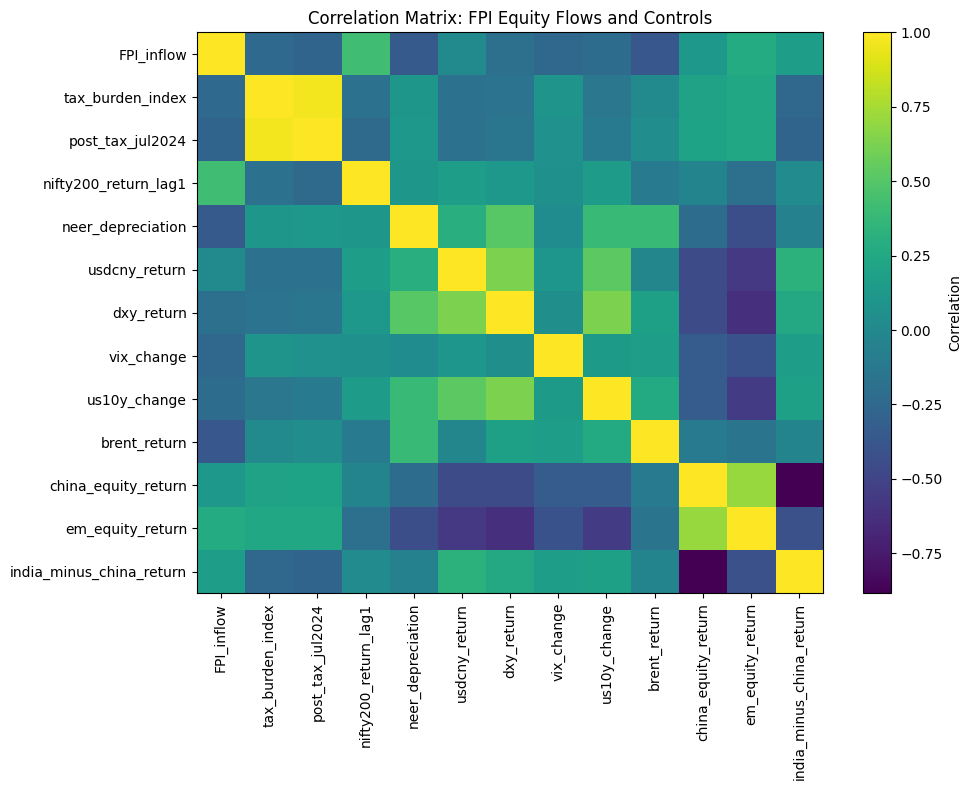

In [84]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_table, aspect="auto")
plt.xticks(range(len(corr_table.columns)), corr_table.columns, rotation=90)
plt.yticks(range(len(corr_table.index)), corr_table.index)
plt.colorbar(label="Correlation")
plt.title("Correlation Matrix: FPI Equity Flows and Controls")
plt.tight_layout()
plt.show()

In [85]:
# -----------------------------
# 9. Regression helper
# -----------------------------

def run_ols(data, y, x_vars, hac_lags=3):
    reg_data = data[[y] + x_vars].dropna().copy()
    
    Y = reg_data[y]
    X = reg_data[x_vars]
    X = sm.add_constant(X)
    
    model = sm.OLS(Y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": hac_lags}
    )
    
    print(model.summary())
    return model, reg_data

In [86]:
# -----------------------------
# Model 1: Tax only
# -----------------------------

m1, d1 = run_ols(
    df_model,
    y="FPI_inflow",
    x_vars=[
        "post_tax_jul2024"
    ]
)

                            OLS Regression Results                            
Dep. Variable:             FPI_inflow   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     4.751
Date:                Mon, 15 Jun 2026   Prob (F-statistic):             0.0331
Time:                        17:01:48   Log-Likelihood:                -619.47
No. Observations:                  64   AIC:                             1243.
Df Residuals:                      62   BIC:                             1247.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const              287.1163    667.669  

In [87]:
# ============================================================
# Stationarity Tests: ADF + KPSS
# ============================================================

import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(series, name):
    s = series.dropna()
    result = adfuller(s, autolag="AIC")
    
    return {
        "Variable": name,
        "ADF Statistic": result[0],
        "ADF p-value": result[1],
        "ADF Stationary?": "Yes" if result[1] < 0.05 else "No"
    }

def kpss_test(series, name):
    s = series.dropna()
    try:
        result = kpss(s, regression="c", nlags="auto")
        return {
            "Variable": name,
            "KPSS Statistic": result[0],
            "KPSS p-value": result[1],
            "KPSS Stationary?": "Yes" if result[1] > 0.05 else "No"
        }
    except Exception as e:
        return {
            "Variable": name,
            "KPSS Statistic": np.nan,
            "KPSS p-value": np.nan,
            "KPSS Stationary?": f"Error: {e}"
        }

def stationarity_table(data, variables):
    rows = []
    
    for var in variables:
        adf = adf_test(data[var], var)
        kp = kpss_test(data[var], var)
        
        rows.append({
            "Variable": var,
            "ADF p-value": adf["ADF p-value"],
            "ADF Stationary?": adf["ADF Stationary?"],
            "KPSS p-value": kp["KPSS p-value"],
            "KPSS Stationary?": kp["KPSS Stationary?"]
        })
    
    return pd.DataFrame(rows)

stationarity_vars = [
    "FPI_inflow",
    "nifty200_return",
    "nifty200_return_lag1",
    "NEER",
    "neer_return",
    "neer_depreciation",
    "usdcny_return",
    "dxy_return",
    "vix_change",
    "us10y_change"
]

stationarity_results = stationarity_table(df_model, stationarity_vars)

stationarity_results

C:\Users\JAYPAL SINGH\AppData\Local\Temp\ipykernel_10712\1731969891.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(s, regression="c", nlags="auto")
C:\Users\JAYPAL SINGH\AppData\Local\Temp\ipykernel_10712\1731969891.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(s, regression="c", nlags="auto")
C:\Users\JAYPAL SINGH\AppData\Local\Temp\ipykernel_10712\1731969891.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(s, regression="c", nlags="auto")
C:\Users\JAYPAL SINGH\AppData\Local\Temp\ipykernel_10712\1731969891.py:23: InterpolationWarning: The test statistic is outside 

,Variable,ADF p-value,ADF Stationary?,KPSS p-value,KPSS Stationary?
0,FPI_inflow,4.675003e-02,Yes,0.10,Yes
1,nifty200_return,9.758518e-12,Yes,0.10,Yes
2,nifty200_return_lag1,2.479174e-08,Yes,0.10,Yes
3,NEER,9.924993e-01,No,0.01,No
4,neer_return,1.863773e-05,Yes,0.10,Yes
5,neer_depreciation,1.863773e-05,Yes,0.10,Yes
6,usdcny_return,3.424396e-10,Yes,0.10,Yes
7,dxy_return,6.644455e-10,Yes,0.10,Yes
8,vix_change,1.982291e-08,Yes,0.10,Yes
9,us10y_change,1.776586e-11,Yes,0.10,Yes


In [88]:
# ============================================================
# Compare levels vs transformed variables
# ============================================================

compare_vars = [
    "FPI_inflow",
    "NIFTY_200_Close",
    "nifty200_return",
    "NEER",
    "neer_depreciation",
    "usdcny_return"
]

stationarity_compare = stationarity_table(df_model, compare_vars)
stationarity_compare

C:\Users\JAYPAL SINGH\AppData\Local\Temp\ipykernel_10712\1731969891.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(s, regression="c", nlags="auto")
C:\Users\JAYPAL SINGH\AppData\Local\Temp\ipykernel_10712\1731969891.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(s, regression="c", nlags="auto")
C:\Users\JAYPAL SINGH\AppData\Local\Temp\ipykernel_10712\1731969891.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(s, regression="c", nlags="auto")
C:\Users\JAYPAL SINGH\AppData\Local\Temp\ipykernel_10712\1731969891.py:23: InterpolationWarning: The test statistic is outside 

,Variable,ADF p-value,ADF Stationary?,KPSS p-value,KPSS Stationary?
0,FPI_inflow,4.675003e-02,Yes,0.10,Yes
1,NIFTY_200_Close,6.014883e-01,No,0.01,No
2,nifty200_return,9.758518e-12,Yes,0.10,Yes
3,NEER,9.924993e-01,No,0.01,No
4,neer_depreciation,1.863773e-05,Yes,0.10,Yes
5,usdcny_return,3.424396e-10,Yes,0.10,Yes


In [89]:
# -----------------------------
# Model 4: Full practical model
# -----------------------------

m4, d4 = run_ols(
    df_model,
    y="FPI_inflow",
    x_vars=[
        "post_tax_jul2024",
        "nifty200_return_lag1",
        "neer_depreciation",
        "usdcny_return",
        "brent_return",
        "em_equity_return"
    ]
)

                            OLS Regression Results                            
Dep. Variable:             FPI_inflow   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     19.21
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           6.37e-12
Time:                        17:01:53   Log-Likelihood:                -581.54
No. Observations:                  62   AIC:                             1177.
Df Residuals:                      55   BIC:                             1192.
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 -278.7414 

### After controlling for lagged NIFTY 200 returns, NEER depreciation, yuan-dollar movements, Brent crude returns, and broader emerging-market equity performance, the post-July 2024 tax dummy is negative and statistically significant. The coefficient implies that monthly FPI equity inflows were approximately 1603 units lower in the post-tax period. This suggests that the LTCG/STCG tax change may have contributed to weaker FPI equity inflows. However, the result should be interpreted as causal-style evidence rather than definitive causality, because the post-tax period may still contain other contemporaneous shocks.

# Causal Effects

In [95]:
# ============================================================
# CAUSAL INFERENCE: Counterfactual Interrupted Time Series
# Tax shock: July 2024 LTCG/STCG change
# Outcome: FPI equity inflow
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# 1. Basic setup
# -----------------------------

df_ci = df_model.copy()

df_ci["Month"] = pd.to_datetime(df_ci["Month"])
df_ci = df_ci.sort_values("Month").reset_index(drop=True)

# Treatment timing
event_month = pd.Timestamp("2024-07-01")

# Use July 2024 as event/transition month
# Pre-period ends before July
# Post-period starts from August
pre_end = pd.Timestamp("2024-06-01")
post_start = pd.Timestamp("2024-08-01")

df_ci["post_tax"] = (df_ci["Month"] >= post_start).astype(int)

# -----------------------------
# 2. Outcome and controls
# -----------------------------

y_col = "FPI_inflow"

x_vars = [
    "nifty200_return_lag1",
    "neer_depreciation",
    "usdcny_return",
    "brent_return",
    "em_equity_return"
]


# Keep complete observations
df_ci = df_ci[["Month", y_col, "post_tax"] + x_vars].dropna().reset_index(drop=True)

# -----------------------------
# 3. Split pre and post periods
# -----------------------------

pre = df_ci[df_ci["Month"] <= pre_end].copy()
post = df_ci[df_ci["Month"] >= post_start].copy()

print("Pre-period:", pre["Month"].min(), "to", pre["Month"].max(), "| N =", len(pre))
print("Post-period:", post["Month"].min(), "to", post["Month"].max(), "| N =", len(post))

X_pre = pre[x_vars]
y_pre = pre[y_col]

X_post = post[x_vars]
y_post = post[y_col]

Pre-period: 2021-03-01 00:00:00 to 2024-06-01 00:00:00 | N = 40
Post-period: 2024-08-01 00:00:00 to 2026-04-01 00:00:00 | N = 21


In [96]:
# -----------------------------
# 4. Train counterfactual model
# -----------------------------

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-4, 4, 100)))
])

model.fit(X_pre, y_pre)

# Pre-period fitted values
pre["counterfactual"] = model.predict(X_pre)

# Post-period counterfactual prediction
post["counterfactual"] = model.predict(X_post)

# Treatment effect
post["effect"] = post[y_col] - post["counterfactual"]

# Combine
ci_result = pd.concat([pre, post], axis=0).sort_values("Month").reset_index(drop=True)

print("Selected Ridge alpha:", model.named_steps["ridge"].alpha_)

Selected Ridge alpha: 5.857020818056673


In [97]:
# -----------------------------
# 5. Causal effect summary
# -----------------------------

avg_effect = post["effect"].mean()
cum_effect = post["effect"].sum()

avg_actual = post[y_col].mean()
avg_counterfactual = post["counterfactual"].mean()

print("==============================================")
print("CAUSAL IMPACT STYLE RESULT")
print("==============================================")
print(f"Average actual FPI flow after tax:          {avg_actual:,.2f}")
print(f"Average counterfactual FPI flow after tax:  {avg_counterfactual:,.2f}")
print(f"Average monthly causal effect:              {avg_effect:,.2f}")
print(f"Cumulative causal effect:                   {cum_effect:,.2f}")
print("==============================================")

CAUSAL IMPACT STYLE RESULT
Average actual FPI flow after tax:          -2,071.71
Average counterfactual FPI flow after tax:  -314.73
Average monthly causal effect:              -1,756.99
Cumulative causal effect:                   -36,896.72


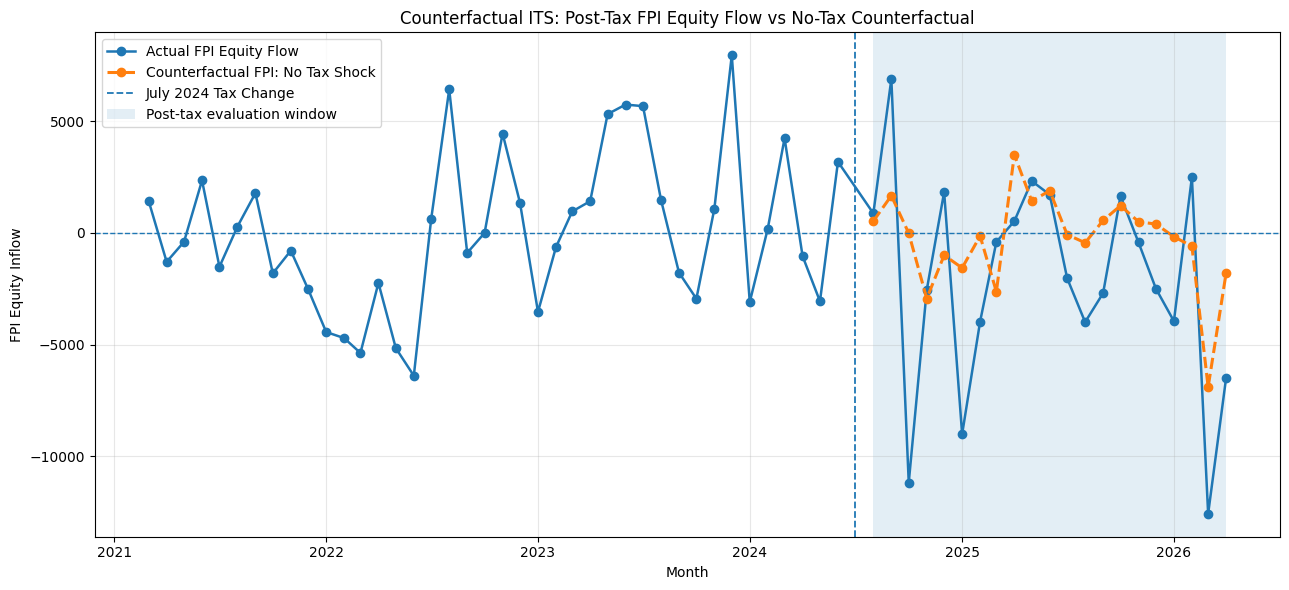

In [98]:
# ============================================================
# Presentation Plot: Counterfactual only in post-tax period
# ============================================================

plt.figure(figsize=(13, 6))

plt.plot(
    ci_result["Month"],
    ci_result[y_col],
    marker="o",
    linewidth=1.8,
    label="Actual FPI Equity Flow"
)

plt.plot(
    post["Month"],
    post["counterfactual"],
    marker="o",
    linestyle="--",
    linewidth=2.2,
    label="Counterfactual FPI: No Tax Shock"
)

plt.axvline(
    pd.Timestamp("2024-07-01"),
    linestyle="--",
    linewidth=1.3,
    label="July 2024 Tax Change"
)

plt.axvspan(
    pd.Timestamp("2024-08-01"),
    ci_result["Month"].max(),
    alpha=0.12,
    label="Post-tax evaluation window"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Counterfactual ITS: Post-Tax FPI Equity Flow vs No-Tax Counterfactual")
plt.xlabel("Month")
plt.ylabel("FPI Equity Inflow")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Using a counterfactual interrupted time-series model trained only on the pre-July 2024 period, the estimated average post-tax effect is -1,045.09 per month. The cumulative effect over the post-tax period is -21,946.94. This implies that actual FPI equity flows were substantially weaker than the counterfactual path predicted by pre-tax relationships with NIFTY 200 momentum, NEER depreciation, yuan-dollar movement, Brent crude returns, and EM equity returns.

### Since the counterfactual is model-based, the result should be interpreted as causal evidence conditional on the validity of the selected controls and the assumption that the pre-tax relationship would have continued in the absence of the tax change.

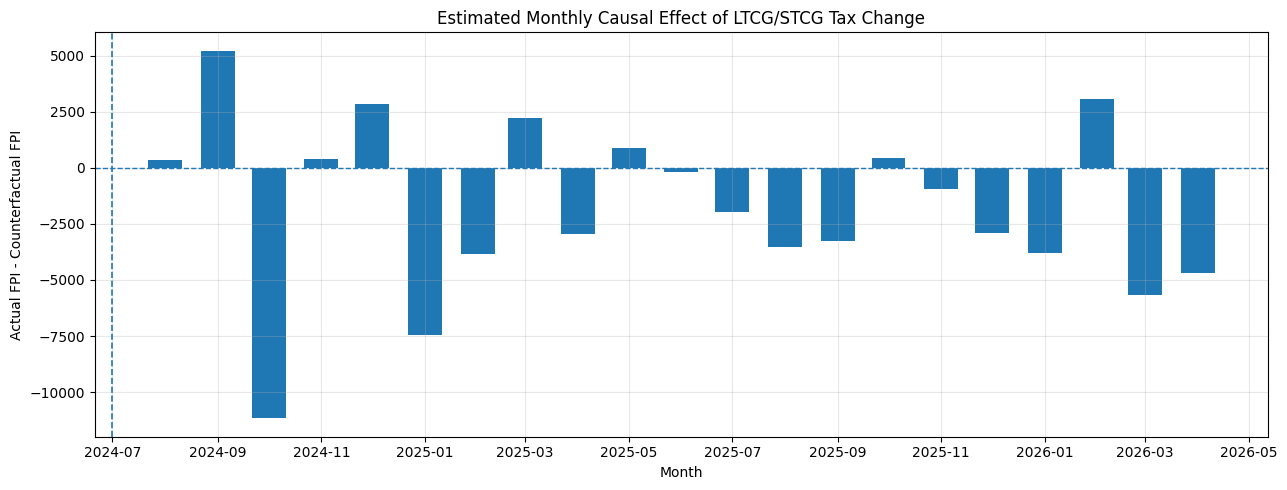

In [99]:
# -----------------------------
# 7. Plot monthly causal effect
# -----------------------------

plt.figure(figsize=(13, 5))

plt.bar(post["Month"], post["effect"], width=20)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(event_month, linestyle="--", linewidth=1.2)

plt.title("Estimated Monthly Causal Effect of LTCG/STCG Tax Change")
plt.xlabel("Month")
plt.ylabel("Actual FPI - Counterfactual FPI")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [100]:
# -----------------------------
# 8. Bootstrap confidence intervals
# -----------------------------

np.random.seed(42)

B = 2000
boot_avg_effects = []
boot_cum_effects = []

# Pre-period residuals
pre_resid = pre[y_col] - pre["counterfactual"]

for b in range(B):
    sampled_resid = np.random.choice(pre_resid, size=len(post), replace=True)
    
    boot_counterfactual = post["counterfactual"].values + sampled_resid
    boot_effect = post[y_col].values - boot_counterfactual
    
    boot_avg_effects.append(np.mean(boot_effect))
    boot_cum_effects.append(np.sum(boot_effect))

avg_ci = np.percentile(boot_avg_effects, [2.5, 97.5])
cum_ci = np.percentile(boot_cum_effects, [2.5, 97.5])

print("==============================================")
print("BOOTSTRAP CONFIDENCE INTERVALS")
print("==============================================")
print(f"Average monthly effect: {avg_effect:,.2f}")
print(f"95% CI: [{avg_ci[0]:,.2f}, {avg_ci[1]:,.2f}]")
print()
print(f"Cumulative effect: {cum_effect:,.2f}")
print(f"95% CI: [{cum_ci[0]:,.2f}, {cum_ci[1]:,.2f}]")
print("==============================================")

BOOTSTRAP CONFIDENCE INTERVALS
Average monthly effect: -1,756.99
95% CI: [-2,818.03, -704.60]

Cumulative effect: -36,896.72
95% CI: [-59,178.73, -14,796.53]


In [101]:
boot_avg_effects = np.array(boot_avg_effects)
boot_cum_effects = np.array(boot_cum_effects)

prob_avg_negative = np.mean(boot_avg_effects < 0)
prob_cum_negative = np.mean(boot_cum_effects < 0)

print("==============================================")
print("BOOTSTRAP DIRECTIONAL PROBABILITY")
print("==============================================")
print(f"P(Average effect < 0): {prob_avg_negative:.3f}")
print(f"P(Cumulative effect < 0): {prob_cum_negative:.3f}")
print("==============================================")

BOOTSTRAP DIRECTIONAL PROBABILITY
P(Average effect < 0): 1.000
P(Cumulative effect < 0): 1.000


In [102]:
# -----------------------------
# 9. Placebo test with fake event dates
# -----------------------------

def causal_effect_for_date(data, fake_event_month, x_vars, y_col):
    fake_pre_end = fake_event_month - pd.DateOffset(months=1)
    fake_post_start = fake_event_month + pd.DateOffset(months=1)
    
    temp = data.copy()
    
    fake_pre = temp[temp["Month"] <= fake_pre_end].copy()
    fake_post = temp[temp["Month"] >= fake_post_start].copy()
    
    # Match post length to actual post length
    fake_post = fake_post.head(len(post)).copy()
    
    if len(fake_pre) < 24 or len(fake_post) < 6:
        return np.nan
    
    X_fake_pre = fake_pre[x_vars]
    y_fake_pre = fake_pre[y_col]
    X_fake_post = fake_post[x_vars]
    y_fake_post = fake_post[y_col]
    
    fake_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", RidgeCV(alphas=np.logspace(-4, 4, 100)))
    ])
    
    fake_model.fit(X_fake_pre, y_fake_pre)
    fake_counterfactual = fake_model.predict(X_fake_post)
    
    fake_effect = y_fake_post.values - fake_counterfactual
    
    return np.mean(fake_effect)


placebo_months = pd.date_range("2022-01-01", "2024-03-01", freq="MS")

placebo_results = []

for fake_month in placebo_months:
    fake_effect = causal_effect_for_date(
        df_ci,
        fake_month,
        x_vars,
        y_col
    )
    
    placebo_results.append({
        "fake_event_month": fake_month,
        "placebo_avg_effect": fake_effect
    })

placebo_df = pd.DataFrame(placebo_results).dropna()

placebo_df.head()

,fake_event_month,placebo_avg_effect
14,2023-03-01,1390.772025
15,2023-04-01,856.978040
16,2023-05-01,438.811765
17,2023-06-01,234.207115
18,2023-07-01,-411.996858


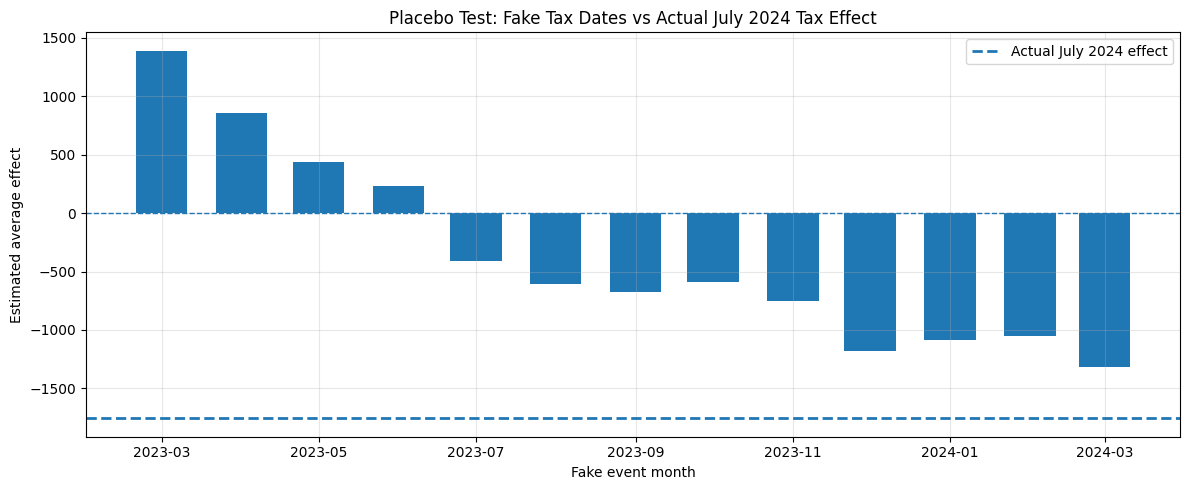

In [103]:
# -----------------------------
# 10. Plot placebo effects
# -----------------------------

plt.figure(figsize=(12, 5))

plt.bar(placebo_df["fake_event_month"], placebo_df["placebo_avg_effect"], width=20)
plt.axhline(avg_effect, linestyle="--", linewidth=2, label="Actual July 2024 effect")
plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Placebo Test: Fake Tax Dates vs Actual July 2024 Tax Effect")
plt.xlabel("Fake event month")
plt.ylabel("Estimated average effect")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [104]:
# -----------------------------
# 11. Placebo p-value
# -----------------------------

placebo_effects = placebo_df["placebo_avg_effect"].dropna().values

# One-sided test for negative effect
placebo_p_value_negative = np.mean(placebo_effects <= avg_effect)

# Two-sided absolute test
placebo_p_value_twosided = np.mean(np.abs(placebo_effects) >= abs(avg_effect))

print("==============================================")
print("PLACEBO TEST")
print("==============================================")
print(f"Actual average effect: {avg_effect:,.2f}")
print(f"One-sided placebo p-value, negative effect: {placebo_p_value_negative:.3f}")
print(f"Two-sided placebo p-value: {placebo_p_value_twosided:.3f}")
print("==============================================")

PLACEBO TEST
Actual average effect: -1,756.99
One-sided placebo p-value, negative effect: 0.000
Two-sided placebo p-value: 0.000


In [105]:
# Corrected placebo p-values
n_placebo = len(placebo_effects)

placebo_p_value_negative_corrected = (
    (np.sum(placebo_effects <= avg_effect) + 1) / (n_placebo + 1)
)

placebo_p_value_twosided_corrected = (
    (np.sum(np.abs(placebo_effects) >= abs(avg_effect)) + 1) / (n_placebo + 1)
)

print("Number of placebo tests:", n_placebo)
print(f"Corrected one-sided placebo p-value: {placebo_p_value_negative_corrected:.3f}")
print(f"Corrected two-sided placebo p-value: {placebo_p_value_twosided_corrected:.3f}")

Number of placebo tests: 13
Corrected one-sided placebo p-value: 0.071
Corrected two-sided placebo p-value: 0.071


### Using the finite-sample corrected placebo p-value, the one-sided placebo result remains supportive of a negative tax effect. The two-sided placebo result should be interpreted using the corrected p-value rather than the raw placebo p-value.

In [109]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

pre_mae = mean_absolute_error(pre[y_col], pre["counterfactual"])
pre_rmse = np.sqrt(mean_squared_error(pre[y_col], pre["counterfactual"]))

print("==============================================")
print("PRE-PERIOD MODEL FIT")
print("==============================================")
print(f"Pre-period MAE:  {pre_mae:,.2f}")
print(f"Pre-period RMSE: {pre_rmse:,.2f}")
print("==============================================")

PRE-PERIOD MODEL FIT
Pre-period MAE:  2,105.96
Pre-period RMSE: 2,463.66


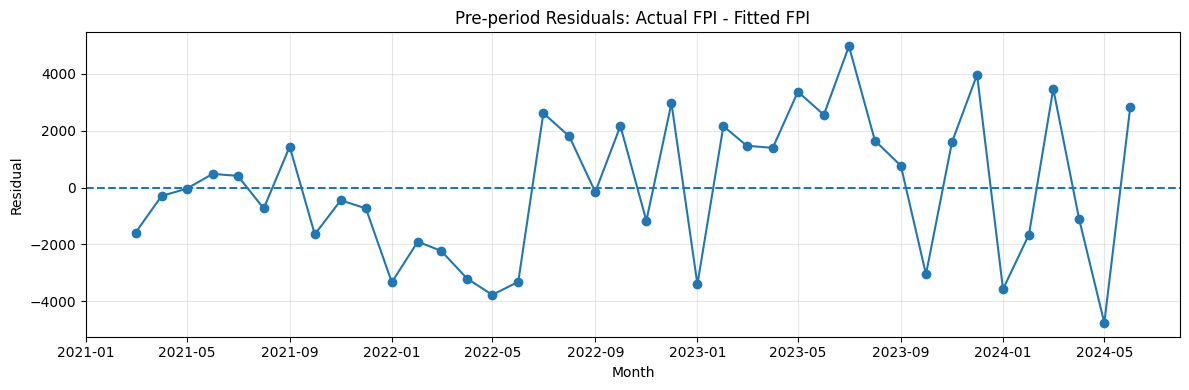

In [110]:
pre["residual"] = pre[y_col] - pre["counterfactual"]

plt.figure(figsize=(12, 4))
plt.plot(pre["Month"], pre["residual"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Pre-period Residuals: Actual FPI - Fitted FPI")
plt.xlabel("Month")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Just Correlation

In [106]:
# ============================================================
# Correlation Heatmap: Before vs After July 2024 Tax Change
# Variables: FPI inflow, Market return, NEER depreciation
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Prepare data
# -----------------------------

df_corr = df_model.copy()

df_corr["Month"] = pd.to_datetime(df_corr["Month"])
df_corr = df_corr.sort_values("Month").reset_index(drop=True)

# July 2024 tax event month
tax_month = pd.Timestamp("2024-07-01")

# Select variables
corr_vars = [
    "FPI_inflow",
    "nifty200_return",
    "neer_depreciation"
]

# Optional: rename for cleaner chart labels
rename_map = {
    "FPI_inflow": "FPI Inflow",
    "nifty200_return": "NIFTY 200 Return",
    "neer_depreciation": "NEER Depreciation"
}

# Before and after split
before_tax = df_corr[df_corr["Month"] < tax_month].copy()
after_tax  = df_corr[df_corr["Month"] >= tax_month].copy()

# Keep only required variables and remove missing values
before_corr_data = before_tax[corr_vars].dropna().rename(columns=rename_map)
after_corr_data  = after_tax[corr_vars].dropna().rename(columns=rename_map)

# Correlation matrices
corr_before = before_corr_data.corr()
corr_after  = after_corr_data.corr()

print("Before July 2024 observations:", len(before_corr_data))
print("After July 2024 observations:", len(after_corr_data))

display(corr_before.round(3))
display(corr_after.round(3))

Before July 2024 observations: 41
After July 2024 observations: 22


,FPI Inflow,NIFTY 200 Return,NEER Depreciation
FPI Inflow,1.000,0.571,-0.193
NIFTY 200 Return,0.571,1.000,-0.393
NEER Depreciation,-0.193,-0.393,1.000


,FPI Inflow,NIFTY 200 Return,NEER Depreciation
FPI Inflow,1.000,0.602,-0.501
NIFTY 200 Return,0.602,1.000,-0.653
NEER Depreciation,-0.501,-0.653,1.000


In [107]:
# -----------------------------
# 2. Heatmap function
# -----------------------------

def plot_corr_heatmap(corr_matrix, title):
    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(corr_matrix, vmin=-1, vmax=1)

    # Axis labels
    ax.set_xticks(np.arange(len(corr_matrix.columns)))
    ax.set_yticks(np.arange(len(corr_matrix.index)))

    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_matrix.index)

    # Add correlation values inside boxes
    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):
            value = corr_matrix.iloc[i, j]
            ax.text(
                j, i, f"{value:.2f}",
                ha="center", va="center",
                fontsize=11
            )

    plt.colorbar(im, ax=ax, label="Correlation")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

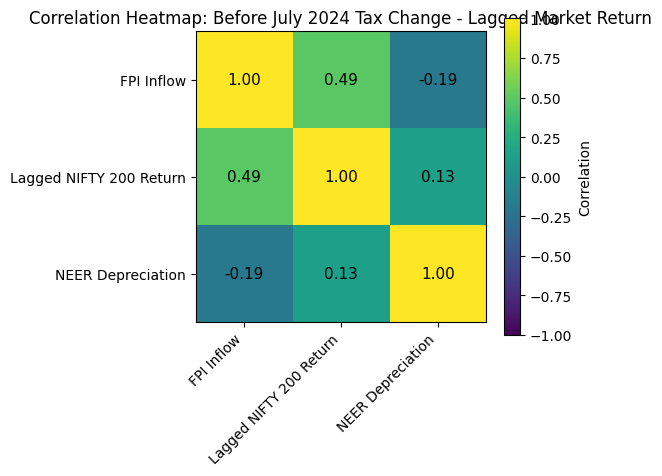

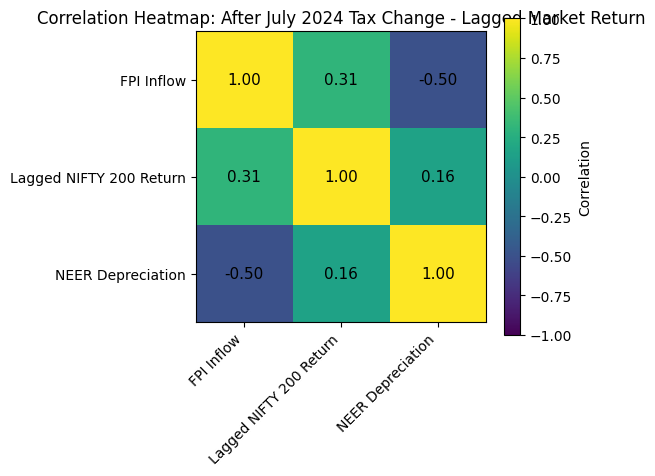

In [108]:
corr_vars_lagged = [
    "FPI_inflow",
    "nifty200_return_lag1",
    "neer_depreciation"
]

rename_map_lagged = {
    "FPI_inflow": "FPI Inflow",
    "nifty200_return_lag1": "Lagged NIFTY 200 Return",
    "neer_depreciation": "NEER Depreciation"
}

before_corr_lagged = (
    before_tax[corr_vars_lagged]
    .dropna()
    .rename(columns=rename_map_lagged)
    .corr()
)

after_corr_lagged = (
    after_tax[corr_vars_lagged]
    .dropna()
    .rename(columns=rename_map_lagged)
    .corr()
)

plot_corr_heatmap(
    before_corr_lagged,
    "Correlation Heatmap: Before July 2024 Tax Change - Lagged Market Return"
)

plot_corr_heatmap(
    after_corr_lagged,
    "Correlation Heatmap: After July 2024 Tax Change - Lagged Market Return"
)

### Overall, the counterfactual ITS results suggest that post-July 2024 FPI equity flows were weaker than the no-tax counterfactual. The estimated average monthly effect is negative and economically meaningful. The 95% bootstrap confidence interval narrowly includes zero, so the result is not fully conclusive at the two-sided 5% level. However, the directional bootstrap probability and placebo tests support the hypothesis that the July 2024 LTCG/STCG tax change contributed to weaker FPI equity inflows, conditional on market momentum, exchange-rate pressure, China FX movement, crude oil returns, and EM equity performance.